# 📊 ETF Portfolio Analysis — PDF Report Generator

Fetches live ETF prices and exports a single-page A4-landscape PDF report.
The reference price column adapts automatically to the chosen **`PERIOD`** preset.

### Available PERIOD presets

| PERIOD | Reference price | Column label |
|--------|----------------|--------------|
| `"1D"`  | Yesterday's close | Ref. Price · 1D |
| `"5D"`  | Close 5 trading days ago | Ref. Price · 5D |
| `"1M"`  | Close ~1 month ago | Ref. Price · 1M |
| `"6M"`  | Close ~6 months ago | Ref. Price · 6M |
| `"YTD"` | First close of the year (Jan 1) | Ref. Price · YTD |
| `"1Y"`  | Close ~1 year ago | Ref. Price · 1Y |
| `"5Y"`  | Close ~5 years ago | Ref. Price · 5Y |
| `"10Y"` | Close ~10 years ago | Ref. Price · 10Y |

### Papermill examples
```bash
papermill etf_portfolio_report.ipynb out.ipynb -p PERIOD 1M
papermill etf_portfolio_report.ipynb out.ipynb -p PERIOD YTD
papermill etf_portfolio_report.ipynb out.ipynb -p PERIOD 1Y
```

> ⚠️ *For informational purposes only. Not financial advice.*

## Cell 2 · Imports

In [6]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.backends.backend_pdf import PdfPages
from datetime import date, timedelta, datetime
from dateutil.relativedelta import relativedelta
import os, warnings
warnings.filterwarnings("ignore")
print("✅  Libraries ready")

✅  Libraries ready


## Cell 3 · Parameters  ← only cell you need to edit

In [ ]:
# ── Period preset — drives reference date, column label, download window ───────
# Choose one of: "1D" | "5D" | "1M" | "6M" | "YTD" | "1Y" | "5Y" | "10Y"
PERIOD = "YTD"

# ── Portfolio tickers ──────────────────────────────────────────────────────────
TICKERS = [
    "IS3N.DE",   # iShares Core MSCI EM IMI
    "EUNL.DE",   # iShares Core MSCI World
    "VWCE.DE",   # Vanguard FTSE All-World Acc
    "IMAE.AS",   # iShares Core MSCI Europe
    "SXR8.DE",   # iShares Core S&P 500
    "SXRV.DE",   # iShares NASDAQ 100 UCITS ETF
]

# ── Portfolio holdings (static — update when you buy/sell) ───────────────────
# Format: "TICKER": (volume_of_shares, avg_purchase_price_per_share)
# HOLDINGS = {
#     "IS3N.DE": (11.1638,  41.31),
#     "EUNL.DE": ( 5.5468, 111.929),
#     "VWCE.DE": ( 4.0848, 147.07),
#     "IMAE.AS": ( 4.5923,  96.79),
#     "SXR8.DE": ( 0.6778, 620.89),
#     "SXRV.DE": ( 0.298,  1229.5),
# }
# Date 28th May 2026 - portfolio holdings - XTB
HOLDINGS = {
    "IS3N.DE": (15.457,  42.928), # iShares Core MSCI EM IMI UCITS ETF USD (Acc)
    "EUNL.DE": ( 5.5468, 111.929), #  iShares Core MSCI World UCITS ETF USD (Acc)
    "VWCE.DE": ( 6.547,  152.95), # Vanguard FTSE All-World UCITS ETF Accumulating
    "IMAE.AS": ( 5.5837,  97.694), # iShares Core MSCI Europe UCITS ETF USD (Acc)
    "SXR8.DE": ( 0.6778, 620.89), # iShares Core S&P 500 UCITS ETF USD (Acc)
    "SXRV.DE": ( 0.298,  1229.50), # iShares NASDAQ 100 UCITS ETF USD (Acc)
}

# ── Gemini API ───────────────────────────────────────────────────────────────
GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY", "")   # or set env var GEMINI_API_KEY

# ── Report identity ────────────────────────────────────────────────────────────
AUTHOR   = "@lbarqueira.bsky.social"
SUBTITLE = "Generated with Python and matplotlib"

## Cell 4 · Resolve PERIOD → reference date, label, download window

In [8]:
TODAY = date.today()

# ── Map each PERIOD preset to:
#    ref_date   : the calendar anchor for the reference price
#    col_label  : short label shown in the table header
#    dl_period  : yfinance download period (must cover ref_date)
#    trading_days_back : if > 0, walk back N trading days instead of calendar date

PERIOD = PERIOD.upper().strip()

PERIOD_MAP = {
    #  preset : (calendar_ref_date_or_None,  trading_days_back,  col_label,  dl_period)
    "1D"  : (None,                             1,   "Ref. Price · 1D",   "5d"),
    "5D"  : (None,                             5,   "Ref. Price · 5D",   "1mo"),
    "1M"  : (TODAY - relativedelta(months=1),  0,   "Ref. Price · 1M",   "3mo"),
    "6M"  : (TODAY - relativedelta(months=6),  0,   "Ref. Price · 6M",   "1y"),
    "YTD" : (date(TODAY.year, 1, 1),           0,   "Ref. Price · YTD",  "1y"),
    "1Y"  : (TODAY - relativedelta(years=1),   0,   "Ref. Price · 1Y",   "2y"),
    "5Y"  : (TODAY - relativedelta(years=5),   0,   "Ref. Price · 5Y",   "10y"),
    "10Y" : (TODAY - relativedelta(years=10),  0,   "Ref. Price · 10Y",  "max"),
}

if PERIOD not in PERIOD_MAP:
    raise ValueError(f"Unknown PERIOD '{PERIOD}'. Choose from: {list(PERIOD_MAP)}")

cal_ref, trading_days_back, COL_LABEL, DL_PERIOD = PERIOD_MAP[PERIOD]

# trading-days-back presets (1D, 5D): REF_DATE is resolved per-ticker from actual
# trading history, so we just store the intent here.
REF_DATE_CALENDAR = cal_ref   # None for 1D/5D — resolved in Cell 5
TRADING_DAYS_BACK = trading_days_back

# Window label for title bar
WINDOW_LABELS = {
    "1D" : "1 Day",   "5D" : "5 Days",  "1M" : "1 Month",
    "6M" : "6 Months","YTD": f"Year-to-Date ({TODAY.year})",
    "1Y" : "1 Year",  "5Y" : "5 Years", "10Y": "10 Years",
}
WINDOW_LABEL = WINDOW_LABELS[PERIOD]

# Output path
now_str     = datetime.now().strftime("%Y-%m-%d_%Hh%Mm")
REPORT_NAME = f"etf_portfolio_{PERIOD}_{now_str}"
os.makedirs(REPORT_NAME, exist_ok=True)
PDF_OUT = os.path.join(REPORT_NAME, f"{REPORT_NAME}.pdf")

print(f"PERIOD        : {PERIOD}")
print(f"Column label  : {COL_LABEL}")
print(f"Ref date      : {'per-ticker (' + str(TRADING_DAYS_BACK) + ' trading days back)' if TRADING_DAYS_BACK else str(REF_DATE_CALENDAR)}")
print(f"Download      : {DL_PERIOD}")
print(f"PDF out       : {PDF_OUT}")

PERIOD        : YTD
Column label  : Ref. Price · YTD
Ref date      : 2026-01-01
Download      : 1y
PDF out       : etf_portfolio_YTD_2026-05-27_02h03m/etf_portfolio_YTD_2026-05-27_02h03m.pdf


## Cell 5 · Download data & compute metrics

In [9]:
FRIENDLY_NAMES = {
    "IS3N.DE" : "iSh Core MSCI EM IMI",
    "EUNL.DE" : "iSh Core MSCI World",
    "VWCE.DE" : "Vanguard FTSE All-World Acc",
    "IMAE.AS" : "iSh Core MSCI Europe",
    "SXR8.DE" : "iSh Core S&P 500",
    "SXRV.DE" : "iSh NASDAQ 100 UCITS ETF",
}

def _get_ref_price(closes, period, cal_ref, trading_days_back):
    """Return (ref_price, actual_ref_date) for a given Close series.

    For calendar-anchored presets (1M, 6M, YTD, 1Y, 5Y, 10Y):
        find the first available trading day on or after cal_ref.
    For trading-day presets (1D, 5D):
        walk back exactly trading_days_back rows in the series.
    """
    closes = closes.sort_index()
    # yfinance may return a tz-aware index (e.g. Europe/Berlin).
    # Strip timezone so comparisons with plain date/Timestamp work correctly.
    if closes.index.tz is not None:
        closes.index = closes.index.tz_localize(None)
    if trading_days_back:
        idx = -(trading_days_back + 1)   # e.g. -2 for 1D (yesterday)
        if abs(idx) > len(closes):
            return None, None
        ref_row   = closes.iloc[idx]
        ref_date  = closes.index[idx].date()
    else:
        anchor = pd.Timestamp(cal_ref)
        window = closes[closes.index >= anchor]
        if window.empty:
            return None, None
        ref_row  = window.iloc[0]
        ref_date = window.index[0].date()
    return round(float(ref_row), 2), ref_date

rows = []
ref_dates_found = []

for ticker in TICKERS:
    tk   = yf.Ticker(ticker)
    hist = tk.history(period=DL_PERIOD, auto_adjust=True)

    if hist.empty:
        print(f"  ⚠️  No data for {ticker}")
        rows.append({"Symbol":ticker, "Name":FRIENDLY_NAMES.get(ticker,ticker),
                     "RefPrice":None, "RefDate":None,
                     "Current":None, "AbsDelta":None, "PctDelta":None})
        continue

    if isinstance(hist.columns, pd.MultiIndex):
        hist.columns = hist.columns.get_level_values(0)

    closes = hist["Close"].dropna()
    ref_price, ref_date = _get_ref_price(closes, PERIOD, REF_DATE_CALENDAR, TRADING_DAYS_BACK)

    if ref_price is None:
        print(f"  ⚠️  Could not resolve reference price for {ticker}")
        rows.append({"Symbol":ticker, "Name":FRIENDLY_NAMES.get(ticker,ticker),
                     "RefPrice":None, "RefDate":None,
                     "Current":None, "AbsDelta":None, "PctDelta":None})
        continue

    current_price = round(float(closes.iloc[-1]), 2)
    abs_delta     = round(current_price - ref_price, 2)
    pct_delta     = round((abs_delta / ref_price) * 100, 2)

    ref_dates_found.append(ref_date)
    rows.append({"Symbol":ticker, "Name":FRIENDLY_NAMES.get(ticker,ticker),
                 "RefPrice":ref_price, "RefDate":ref_date,
                 "Current":current_price, "AbsDelta":abs_delta, "PctDelta":pct_delta})

    print(f"  ✅  {ticker:12s}  {COL_LABEL}={ref_price:>10.2f}  "
          f"Now={current_price:>10.2f}  Δ={abs_delta:>+8.2f}  {pct_delta:>+6.2f}%  "
          f"(ref date: {ref_date})")

df = pd.DataFrame(rows)

# Representative reference date for the header (most common across tickers)
DISPLAY_REF_DATE = max(set(ref_dates_found), key=ref_dates_found.count) if ref_dates_found else None
print(f"\n✅  {len(df)} tickers processed.  Display ref date: {DISPLAY_REF_DATE}")

  ✅  IS3N.DE       Ref. Price · YTD=     39.14  Now=     47.40  Δ=   +8.26  +21.10%  (ref date: 2026-01-02)
  ✅  EUNL.DE       Ref. Price · YTD=    111.32  Now=    123.50  Δ=  +12.18  +10.94%  (ref date: 2026-01-02)
  ✅  VWCE.DE       Ref. Price · YTD=    145.14  Now=    162.78  Δ=  +17.64  +12.15%  (ref date: 2026-01-02)
  ✅  IMAE.AS       Ref. Price · YTD=     94.61  Now=    101.27  Δ=   +6.66   +7.04%  (ref date: 2026-01-02)
  ✅  SXR8.DE       Ref. Price · YTD=    624.74  Now=    696.54  Δ=  +71.80  +11.49%  (ref date: 2026-01-02)
  ✅  SXRV.DE       Ref. Price · YTD=   1248.40  Now=   1472.40  Δ= +224.00  +17.94%  (ref date: 2026-01-05)

✅  6 tickers processed.  Display ref date: 2026-01-02


## Cell 6 · Build & export PDF

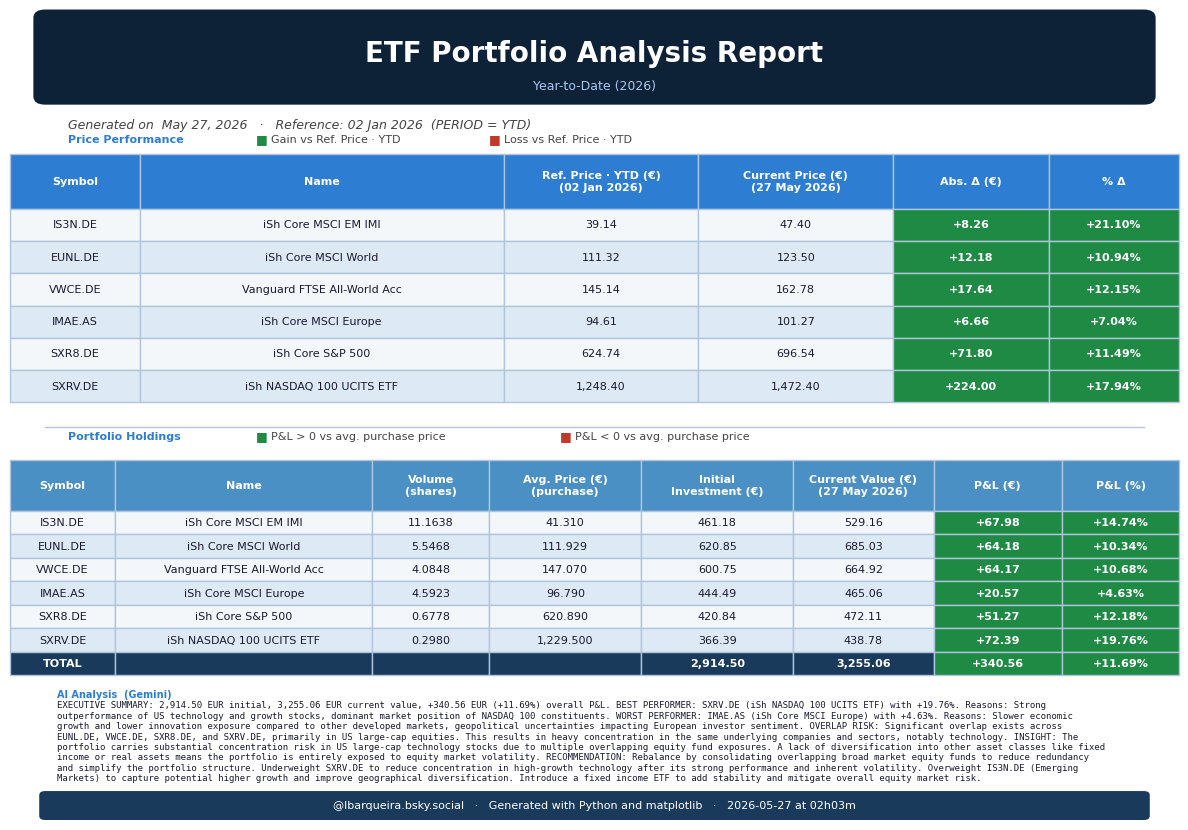


✅  Report saved → etf_portfolio_YTD_2026-05-27_02h03m/etf_portfolio_YTD_2026-05-27_02h03m.pdf


In [10]:
C_BLUE_DARK="#0D2137"; C_BLUE_MID="#1A3A5C"; C_ACCENT="#2D7DD2"
C_GREEN="#1E8A44"; C_RED="#C0392B"; C_WHITE="#FFFFFF"
C_ROW_LIGHT="#F4F7FA"; C_ROW_DARK="#DDEAF6"; C_BORDER="#B0C4DE"
C_HDR2="#4A90C4"   # slightly lighter blue for the holdings table header

ref_date_str = DISPLAY_REF_DATE.strftime('%d %b %Y') if DISPLAY_REF_DATE else "N/A"

# ── Table 1: price performance ────────────────────────────────────────────────
col_labels = [
    "Symbol", "Name",
    f"{COL_LABEL} (€)\n({ref_date_str})",
    f"Current Price (€)\n({TODAY.strftime('%d %b %Y')})",
    "Abs. Δ (€)", "% Δ",
]
cell_text=[]; cell_colors=[]
for i, row in df.iterrows():
    try:
        pct   = float(row["PctDelta"])
        dc    = C_GREEN if pct >= 0 else C_RED
        pct_s = f"{pct:+.2f}%"
        abs_s = f"{float(row['AbsDelta']):+.2f}"
    except (TypeError, ValueError):
        dc = "#666666"; pct_s = abs_s = "N/A"
    try:
        ref_s = f"{float(row['RefPrice']):,.2f}"
        cur_s = f"{float(row['Current']):,.2f}"
    except (TypeError, ValueError):
        ref_s = cur_s = "N/A"
    bg = C_ROW_LIGHT if i % 2 == 0 else C_ROW_DARK
    cell_text.append([row["Symbol"], row["Name"], ref_s, cur_s, abs_s, pct_s])
    cell_colors.append([bg, bg, bg, bg,
                        dc if abs_s != "N/A" else bg,
                        dc if pct_s != "N/A" else bg])

# ── Table 2: portfolio holdings ───────────────────────────────────────────────
# Holdings table: static cost-basis columns + live P&L vs current price
h_col_labels = [
    "Symbol", "Name",
    "Volume\n(shares)",
    "Avg. Price (€)\n(purchase)",
    "Initial\nInvestment (€)",
    f"Current Value (€)\n({TODAY.strftime('%d %b %Y')})",
    "P&L (€)",
    "P&L (%)",
]
h_cell_text=[]; h_cell_colors=[]
total_initial = 0; total_cur_value = 0; total_pnl_abs = 0
for i, ticker in enumerate(TICKERS):
    vol, avg_price  = HOLDINGS.get(ticker, (0, 0))
    initial_inv     = round(vol * avg_price, 2)
    # current price from the live df fetched earlier
    cur_price_row   = df[df["Symbol"] == ticker]
    cur_price       = float(cur_price_row["Current"].iloc[0]) if not cur_price_row.empty else None
    name            = FRIENDLY_NAMES.get(ticker, ticker)
    bg = C_ROW_LIGHT if i % 2 == 0 else C_ROW_DARK
    if cur_price is not None:
        cur_value   = round(vol * cur_price, 2)
        pnl_abs     = round(cur_value - initial_inv, 2)
        pnl_pct     = round((pnl_abs / initial_inv) * 100, 2) if initial_inv else 0
        pnl_color   = C_GREEN if pnl_abs >= 0 else C_RED
        cur_val_s   = f"{cur_value:,.2f}"
        pnl_abs_s   = f"{pnl_abs:+,.2f}"
        pnl_pct_s   = f"{pnl_pct:+.2f}%"
        total_initial   += initial_inv
        total_cur_value += cur_value
        total_pnl_abs   += pnl_abs
    else:
        pnl_color = "#666666"
        cur_val_s = pnl_abs_s = pnl_pct_s = "N/A"
    h_cell_text.append([ticker, name,
                        f"{vol:,.4f}",
                        f"{avg_price:,.3f}",
                        f"{initial_inv:,.2f}",
                        cur_val_s, pnl_abs_s, pnl_pct_s])
    h_cell_colors.append([bg, bg, bg, bg, bg, bg, pnl_color, pnl_color])

# Totals row
total_pnl_pct   = round((total_pnl_abs / total_initial) * 100, 2) if total_initial else 0
total_pnl_color = C_GREEN if total_pnl_abs >= 0 else C_RED
h_cell_text.append(["TOTAL", "", "", "",
                    f"{total_initial:,.2f}",
                    f"{total_cur_value:,.2f}",
                    f"{total_pnl_abs:+,.2f}",
                    f"{total_pnl_pct:+.2f}%"])
h_cell_colors.append([C_BLUE_MID, C_BLUE_MID, C_BLUE_MID, C_BLUE_MID,
                       C_BLUE_MID, C_BLUE_MID, total_pnl_color, total_pnl_color])

# ── Figure — two axes stacked vertically ──────────────────────────────────────
fig = plt.figure(figsize=(11.69, 8.27))
fig.patch.set_facecolor(C_WHITE)

# ax1: price table  (upper half of the body)
# ax2: holdings table (lower half of the body)
# Both are plain axes with axis off — tables are drawn inside them.
ax1 = fig.add_axes([0.0, 0.51, 1.0, 0.30])   # [left, bottom, width, height]
ax2 = fig.add_axes([0.0, 0.18, 1.0, 0.26])  # [left, bottom, width, height]
ax1.set_axis_off()
ax2.set_axis_off()

# ── Title bar ──────────────────────────────────────────────────────────────────
fig.add_artist(mpatches.FancyBboxPatch((0.03,0.88),0.94,0.10-0.005,
    boxstyle="round,pad=0.01",linewidth=0,facecolor=C_BLUE_DARK,
    transform=fig.transFigure,clip_on=False))
fig.text(0.50,0.932,"ETF Portfolio Analysis Report",
         ha="center",va="center",fontsize=20,fontweight="bold",
         color=C_WHITE,transform=fig.transFigure)
fig.text(0.50,0.893,WINDOW_LABEL,
         ha="center",va="center",fontsize=9,color="#A8C8F0",
         transform=fig.transFigure)

# ── Date line ──────────────────────────────────────────────────────────────────
fig.text(0.05,0.845,
         f"Generated on  {TODAY.strftime('%B %d, %Y')}   ·   "
         f"Reference: {ref_date_str}  (PERIOD = {PERIOD})",
         ha="left",va="center",fontsize=9,color="#444444",style="italic",
         transform=fig.transFigure)
# fig.add_artist(plt.Line2D([0.03,0.97],[0.868,0.868],lw=2.5,color=C_ACCENT,
#                           transform=fig.transFigure,clip_on=False))

# ── Section label: Performance ─────────────────────────────────────────────────
fig.text(0.05,0.828,"Price Performance",
         ha="left",va="center",fontsize=8,fontweight="bold",color=C_ACCENT,
         transform=fig.transFigure)
# Legend for Price Performance table
for x,color,label in[(0.21,C_GREEN,f"Gain vs {COL_LABEL}"),
                      (0.41,C_RED,  f"Loss vs {COL_LABEL}")]:
    fig.text(x,      0.828,"■",color=color,fontsize=9,
             transform=fig.transFigure,va="center")
    fig.text(x+0.013,0.828,label,fontsize=8,color="#444444",
             transform=fig.transFigure,va="center")

# ── Price table (ax1) ──────────────────────────────────────────────────────────
tbl = ax1.table(cellText=cell_text,colLabels=col_labels,
                cellLoc="center",loc="center",bbox=[0.0,0.0,1.0,1.0])
tbl.auto_set_font_size(False); tbl.set_fontsize(8)

for c in range(len(col_labels)):
    cell=tbl[0,c]; cell.set_facecolor(C_ACCENT)
    cell.set_text_props(color=C_WHITE,fontweight="bold",fontsize=8)
    cell.set_edgecolor(C_BORDER); cell.set_height(0.22)
for r in range(1,len(df)+1):
    for c in range(len(col_labels)):
        cell=tbl[r,c]; cell.set_facecolor(cell_colors[r-1][c])
        cell.set_edgecolor(C_BORDER); cell.set_height(0.13)
        if c in(4,5) and cell_colors[r-1][c] in(C_GREEN,C_RED):
            cell.set_text_props(color=C_WHITE,fontweight="bold")
        else:
            cell.set_text_props(color="#1A1A2E")
for c,w in enumerate([0.10,0.28,0.15,0.15,0.12,0.10]):
    for r in range(len(df)+1): tbl[r,c].set_width(w)

# ── Divider + section label: Holdings ─────────────────────────────────────────
fig.add_artist(plt.Line2D([0.03,0.97],[0.480,0.480],lw=1.0,color=C_BORDER,
                          transform=fig.transFigure,clip_on=False))
fig.text(0.05,0.389 + 0.08,"Portfolio Holdings",
         ha="left",va="center",fontsize=8,fontweight="bold",color=C_ACCENT,
         transform=fig.transFigure)
# Legend for Portfolio Holdings table
for x,color,label in[(0.21,C_GREEN,"P&L > 0 vs avg. purchase price"),
                      (0.47,C_RED,  "P&L < 0 vs avg. purchase price")]:
    fig.text(x,      0.389 + 0.08,"■",color=color,fontsize=9,
             transform=fig.transFigure,va="center")
    fig.text(x+0.013,0.389 + 0.08,label,fontsize=8,color="#444444",
             transform=fig.transFigure,va="center")

# ── Holdings table (ax2) ───────────────────────────────────────────────────────
htbl = ax2.table(cellText=h_cell_text,colLabels=h_col_labels,
                 cellLoc="center",loc="center",bbox=[0.0,0.0,1.0,1.0])
htbl.auto_set_font_size(False); htbl.set_fontsize(8)

for c in range(len(h_col_labels)):
    cell=htbl[0,c]; cell.set_facecolor(C_HDR2)
    cell.set_text_props(color=C_WHITE,fontweight="bold",fontsize=8)
    cell.set_edgecolor(C_BORDER); cell.set_height(0.28)
for r in range(1,len(TICKERS)+1):
    for c in range(len(h_col_labels)):
        cell=htbl[r,c]; cell.set_facecolor(h_cell_colors[r-1][c])
        cell.set_edgecolor(C_BORDER); cell.set_height(0.13)
        if c in (6,7) and h_cell_colors[r-1][c] in (C_GREEN, C_RED):
            cell.set_text_props(color=C_WHITE,fontweight="bold")
        else:
            cell.set_text_props(color="#1A1A2E")
for c,w in enumerate([0.09, 0.22, 0.10, 0.13, 0.13, 0.12, 0.11, 0.10]):
    for r in range(len(TICKERS)+2): htbl[r,c].set_width(w)
# Totals row styling
totals_row = len(TICKERS) + 1
for c in range(len(h_col_labels)):
    cell = htbl[totals_row, c]
    cell.set_facecolor(h_cell_colors[totals_row-1][c])
    cell.set_edgecolor(C_BORDER); cell.set_height(0.13)
    if c in (6, 7):
        cell.set_text_props(color=C_WHITE, fontweight="bold")
    else:
        cell.set_text_props(color=C_WHITE, fontweight="bold")

# ── Gemini analysis ──────────────────────────────────────────────────────────
import os, textwrap, time
try:
    from google import genai as _genai
    _api_key = GEMINI_API_KEY or os.environ.get("GEMINI_API_KEY", "")
    if not _api_key:
        raise ValueError("No Gemini API key found.")
    _client = _genai.Client(api_key=_api_key)
    # Full per-ETF data including live P&L so Gemini can identify best/worst
    _holdings_summary = "\n".join([
        f"{row['Symbol']} ({FRIENDLY_NAMES.get(row['Symbol'], row['Symbol'])}):\n"
        f"  vol={HOLDINGS[row['Symbol']][0]:.4f} shares, "
        f"avg_purchase={HOLDINGS[row['Symbol']][1]:.3f} EUR, "
        f"initial={HOLDINGS[row['Symbol']][0]*HOLDINGS[row['Symbol']][1]:.2f} EUR, "
        f"current_price={row['Current']:.2f} EUR, "
        f"current_value={HOLDINGS[row['Symbol']][0]*row['Current']:.2f} EUR, "
        f"pnl={HOLDINGS[row['Symbol']][0]*row['Current'] - HOLDINGS[row['Symbol']][0]*HOLDINGS[row['Symbol']][1]:+.2f} EUR "
        f"({(HOLDINGS[row['Symbol']][0]*row['Current'] - HOLDINGS[row['Symbol']][0]*HOLDINGS[row['Symbol']][1]) / (HOLDINGS[row['Symbol']][0]*HOLDINGS[row['Symbol']][1])*100:+.2f}%)"
        for _, row in df.iterrows()
    ])
    _prompt = (
        "You are an expert financial analyst. Analyze the following ETF portfolio. "
        "Respond in plain text only, no markdown, no introductory sentences, no closing remarks, no disclaimers. "
        "Start directly with EXECUTIVE SUMMARY. "
        "Use exactly this structure (one line each):\n"
        "EXECUTIVE SUMMARY: total initial investment, current value, overall P&L (EUR and %).\n"
        "BEST PERFORMER: ETF with highest P&L% and two reasons.\n"
        "WORST PERFORMER: ETF with lowest P&L% and two reasons.\n"
        "OVERLAP RISK: note any significant index overlaps in two sentences.\n"
        "INSIGHT: two concise observations about diversification or concentration risk.\n"
        "RECOMMENDATION: four actionable observations (rebalance, overweight, underweight, or hold).\n\n"
        f"Report date: {TODAY.strftime('%B %d, %Y')} | Currency: EUR\n"
        "Note: P&L is calculated vs average purchase price (cost basis), not vs a time period.\n\n"
        f"PORTFOLIO HOLDINGS:\n{_holdings_summary}\n"
        f"Total initial: {total_initial:,.2f} EUR | "
        f"Current value: {total_cur_value:,.2f} EUR | "
        f"P&L: {total_pnl_abs:+,.2f} EUR ({total_pnl_pct:+.2f}%)"
    )
    for _attempt in range(3):
        try:
            _response   = _client.models.generate_content(
                model="gemini-2.5-flash",
                contents=_prompt
            )
            gemini_text = _response.text.strip()
            break
        except Exception as _e:
            if _attempt < 2:
                time.sleep(30)
            else:
                gemini_text = f"Gemini analysis unavailable: {_e}"
except Exception as e:
    gemini_text = f"Gemini analysis unavailable: {e}"

# Render Gemini text below the second table
fig.text(0.04, 0.118+0.045, "AI Analysis  (Gemini)",
         ha="left", va="top", fontsize=7, fontweight="bold", color=C_ACCENT,
         transform=fig.transFigure)
_wrapped = textwrap.fill(gemini_text, width=195)
fig.text(0.04, 0.104+0.045, _wrapped,
         ha="left", va="top", fontsize=6.5, color="#1A1A2E",
         transform=fig.transFigure, wrap=True,
         family="monospace")

# ── Footer ─────────────────────────────────────────────────────────────────────
fig.add_artist(mpatches.FancyBboxPatch((0.03,0.01),0.94,0.025,
    boxstyle="round,pad=0.005",linewidth=0,facecolor=C_BLUE_MID,
    transform=fig.transFigure,clip_on=False))
fig.text(0.50,0.032-0.01,f"{AUTHOR}   ·   {SUBTITLE}   ·   {datetime.now().strftime('%Y-%m-%d at %Hh%Mm')}",
         ha="center",va="center",fontsize=8,color=C_WHITE,
         transform=fig.transFigure)

with PdfPages(PDF_OUT) as pdf:
    pdf.savefig(fig,bbox_inches="tight",dpi=150)
plt.show()
print(f"\n✅  Report saved → {PDF_OUT}")